In [4]:
import pandas as pd
import pickle
import dask.dataframe as dd

import matplotlib.pyplot as plt
import seaborn as sns
import math

import subprocess

In [5]:
## 8 lineages adn significant 
lineages = ['4_1803', '5_2505', '1_4562' ]

# 12 lineages most significant 
lineages = ['1_4847']

genes = ['4_1803', '5_2505', '1_4562','1_4847' ]

In [6]:
dict_blocks = '../key_files/blocks_snpsid_dict.pkl'

with open(dict_blocks, 'rb') as file:
    dict_blocks = pickle.load(file)

reverse_mapping = {item: key for key, values in dict_blocks.items() for item in values}

In [7]:
snps_dict = pd.read_csv('../key_files/var_pos_grenenet.csv')

In [8]:
snps_dict['block'] = snps_dict['id'].map(reverse_mapping)

In [9]:
snps_dict_filt = snps_dict[snps_dict['block'].isin(genes)]

In [10]:
for i in genes:
    print(snps_dict[snps_dict['block'].isin([i])].index.values[0] + 2)
    print(snps_dict[snps_dict['block'].isin([i])].index.values[-1] + 2)

2298899
2299020
3114144
3114253
705311
705415
740189
740276


In [11]:
awk_command = "awk 'NR >= 2298899 && NR <= 2299020 || NR >= 3114144 && NR <= 3114253 || NR >= 705311 && NR <= 705415 || NR >= 740189 && NR <= 740276' ../baypass_terminal/merged_hapFIRE_allele_frequency_indexed.csv > af_lineages.csv"
# Run the command using subprocess
subprocess.run(awk_command, shell=True, check=True)

CompletedProcess(args="awk 'NR >= 2298899 && NR <= 2299020 || NR >= 3114144 && NR <= 3114253 || NR >= 705311 && NR <= 705415 || NR >= 740189 && NR <= 740276' ../baypass_terminal/merged_hapFIRE_allele_frequency_indexed.csv > af_lineages.csv", returncode=0)

In [ ]:
#awk 'NR >= 845212 && NR <= 845232 || NR >= 1868509 && NR <= 1868608 || NR >= 3053517 && NR <= 3053587' ../baypass_terminal/merged_hapFIRE_allele_frequency_indexed.csv > filtered_blocks.csv

In [ ]:
#awk 'NR >= 845212 && NR <= 845232 || NR >= 1868509 && NR <= 1868608 || NR >= 3053517 && NR <= 3053587' ../key_files/merged_hapFIRE_delta_p.txt > filtered_blocks_deltap.csv

In [18]:
## allele counts
af = pd.read_csv('af_lineages.csv',header=None)
usecols = pd.read_csv('../baypass_terminal/merged_hapFIRE_allele_frequency_indexed.csv',nrows =1).columns 
af.columns = usecols

In [19]:
af

,1_1_1,1_1_2,1_1_3,1_1_4,1_1_5,1_1_6,1_1_7,1_1_8,1_1_9,1_1_10,...,60_1_5,60_1_6,60_1_7,60_1_8,60_1_9,60_1_10,60_1_11,60_1_12,Unnamed: 745,0
0,0.004389,0.001571,0.001818,0.010704,0.001792,0.002393,0.002777,0.002638,0.002491,0.002452,...,0.000225,0.000928,0.001191,0.000230,0.000000,0.002127,0.000000,0.000819,705309,1_25508331
1,0.016146,0.007320,0.018383,0.001051,0.000693,0.002035,0.016413,0.000434,0.000933,0.001022,...,0.000117,0.000311,0.000000,0.000275,0.001709,0.000292,0.000229,0.000392,705310,1_25508335
2,0.058421,0.032587,0.012016,0.026803,0.034254,0.040374,0.042240,0.042370,0.033150,0.058841,...,0.120138,0.095856,0.001571,0.003975,0.285971,0.006938,0.338340,0.061407,705311,1_25508367
3,0.002324,0.014003,0.005698,0.009830,0.002873,0.002491,0.003015,0.001310,0.014322,0.007906,...,0.000944,0.000398,0.001752,0.000731,0.001377,0.000722,0.000450,0.000840,705312,1_25508409
4,0.001927,0.006236,0.004397,0.002170,0.001511,0.004697,0.001386,0.005402,0.001813,0.001599,...,0.000247,0.000307,0.000455,0.000513,0.000912,0.001438,0.000223,0.000369,705313,1_25508528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420,0.048961,0.014866,0.020222,0.044171,0.018809,0.038357,0.028944,0.030413,0.019541,0.034485,...,0.000981,0.101823,0.012124,0.049231,0.003999,0.009303,0.001085,0.026137,3114247,5_21991539
421,0.041241,0.054095,0.018737,0.040234,0.048951,0.034515,0.042368,0.040022,0.027356,0.029790,...,0.036371,0.062467,0.043389,0.007904,0.010902,0.008190,0.065116,0.044428,3114248,5_21991557
422,0.044334,0.055265,0.084236,0.046675,0.063788,0.065972,0.031116,0.040013,0.066876,0.037408,...,0.118753,0.014543,0.229813,0.102209,0.180680,0.063267,0.003325,0.159098,3114249,5_21991581
423,0.041241,0.054095,0.018737,0.040234,0.048951,0.034515,0.042368,0.040022,0.027356,0.029790,...,0.036371,0.062467,0.043389,0.007904,0.010902,0.008190,0.065116,0.044428,3114250,5_21991593


In [20]:
snps_dict_filt = snps_dict_filt.reset_index(drop=True)

In [21]:
causal = pd.concat([af, snps_dict_filt],axis=1)

causal = causal[causal['total_alleles05filter'].notna()]

causal_det = causal[['pos', 'chrom', 'maf05filter', 'total_alleles05filter', 'block']].copy()

causal =causal.drop(['pos', 'chrom', 'maf05filter', 'total_alleles05filter', 'block'],axis=1).set_index('id')

In [22]:
first_gen = pd.read_csv('../key_files/generation_1_sample_names.txt',header=None)[0]

In [23]:
causal_first_gen = causal[first_gen]

In [24]:
causal_loci_save = causal.index

In [25]:
causal_values = causal_first_gen.reset_index().drop(columns='id').T

In [26]:
samples = causal_first_gen.columns

#clim_sites_during_exp = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/grene/data/bioclimvars_experimental_sites_era5.csv')
clim_sites_during_exp = pd.read_csv('../key_files/bioclimvars_sites_era5_year_2018.csv')

sites_af = pd.Series(samples).str.split('_').str[0].astype(int)

sites_af.name = 'site'

env = sites_af.reset_index().merge(clim_sites_during_exp).drop(['index'],axis=1)

bio1 = env['bio1']

In [27]:
bio1.index = causal_values.index

In [30]:
colors = sns.color_palette("viridis", n_colors = 4)

# Create a dictionary that maps each block to a specific color
block_color_dict = {
    genes[0]: colors[0],
    genes[1]: colors[1],
    genes[2]: colors[2],
    genes[3]: colors[3],
}

In [31]:
causal_det = causal_det.reset_index(drop=True)

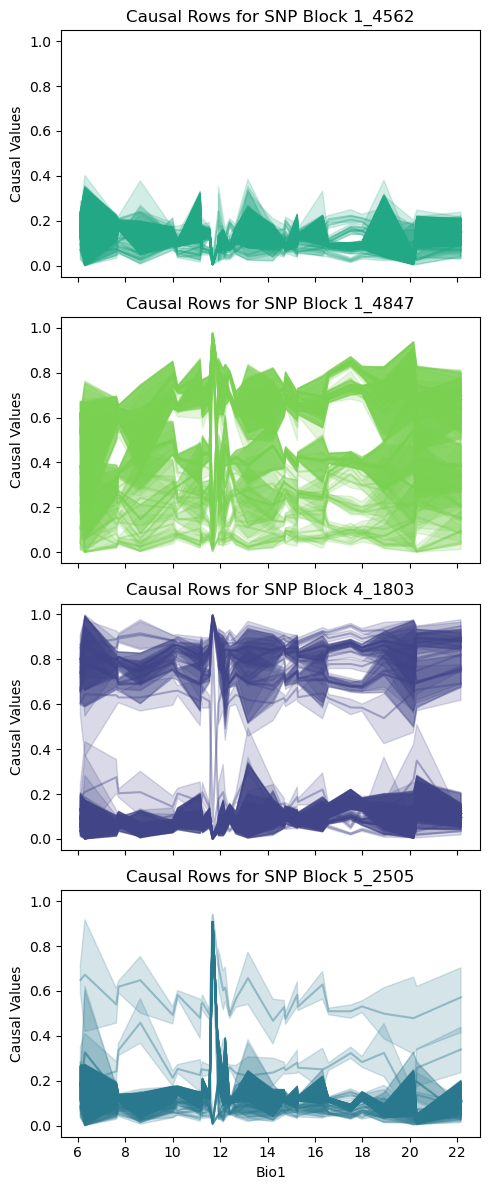

In [32]:
from scipy.stats import linregress


r2 = {}
# Identify unique blocks from your data
unique_blocks = causal_det['block'].unique()

# Create subplots: one for each unique block
fig, axes = plt.subplots(nrows=len(unique_blocks), figsize=(5, 3 * len(unique_blocks)), sharex=True,sharey=True)

# If there's only one unique block, `axes` will not be an array, so we make it one
if len(unique_blocks) == 1:
    axes = [axes]

# Plot each row of causal as a line in the corresponding subplot
for i, block in enumerate(unique_blocks):
    # Filter the rows corresponding to the current block
    block_rows = causal_det[causal_det['block'] == block].index
    color = block_color_dict[block]
    
    for row in block_rows:
        # Perform linear regression between bio1 and the current row of causal values
        slope, intercept, r_value, p_value, std_err = linregress(bio1, causal_values[row])
        
        # Plot the causal values for this row
        sns.lineplot(x=bio1, y=causal_values[row], ax=axes[i], label=f'Row {row + 1}', color=color, alpha=0.4, legend=False)
        
        # Annotate the plot with the R-squared value
        r2[row] = [slope, r_value, p_value]
    
    # Set labels and title for each subplot
    axes[i].set_title(f'Causal Rows for SNP Block {block}')
    axes[i].set_xlabel('Bio1')
    axes[i].set_ylabel('Causal Values')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()


In [33]:
rs = pd.DataFrame(r2).T

rs.columns = ['slope', 'r2', 'p']

blocks_snps = pd.concat([causal_det, rs],axis=1)

blocks_snps['r_squared']  = blocks_snps['r2'] ** 2

In [36]:
#blocks_snps.to_csv('blocks_snps_r2_af_lineages.csv',index=None)

In [37]:
blocks_snps.sort_values('r_squared', ascending=False)

,pos,chrom,maf05filter,total_alleles05filter,block,slope,r2,p,r_squared
147,9749690,4,4_9749690,4_9749690,4_1803,0.004291,0.300151,3.267105e-08,9.009035e-02
78,26598733,1,1_26598733,1_26598733,1_4847,0.011431,0.299310,3.583186e-08,8.958634e-02
145,9749664,4,4_9749664,4_9749664,4_1803,0.003805,0.289420,1.038677e-07,8.376392e-02
152,9749954,4,4_9749954,4_9749954,4_1803,0.003805,0.289420,1.038677e-07,8.376392e-02
150,9749803,4,4_9749803,4_9749803,4_1803,0.003805,0.289420,1.038677e-07,8.376392e-02
...,...,...,...,...,...,...,...,...,...
68,26597893,1,1_26597893,1_26597893,1_4847,0.000084,0.002716,9.610333e-01,7.378621e-06
99,9746970,4,4_9746970,4_9746970,4_1803,0.000036,0.001153,9.834557e-01,1.329246e-06
154,21988487,5,5_21988487,5_21988487,5_2505,-0.000032,-0.001062,9.847668e-01,1.126884e-06
140,9749010,4,4_9749010,4_9749010,4_1803,0.000027,0.000730,9.895255e-01,5.327668e-07


In [38]:
blocks_snps.sort_values('slope', ascending=False)

,pos,chrom,maf05filter,total_alleles05filter,block,slope,r2,p,r_squared
78,26598733,1,1_26598733,1_26598733,1_4847,0.011431,0.299310,3.583186e-08,0.089586
80,26598994,1,1_26598994,1_26598994,1_4847,0.010389,0.284587,1.721896e-07,0.080990
73,26598054,1,1_26598054,1_26598054,1_4847,0.009789,0.274026,5.029920e-07,0.075090
72,26598045,1,1_26598045,1_26598045,1_4847,0.009758,0.273075,5.527428e-07,0.074570
70,26598020,1,1_26598020,1_26598020,1_4847,0.009758,0.273075,5.527428e-07,0.074570
...,...,...,...,...,...,...,...,...,...
170,21989769,5,5_21989769,5_21989769,5_2505,-0.004878,-0.180058,1.093591e-03,0.032421
168,21989463,5,5_21989463,5_21989463,5_2505,-0.004878,-0.180058,1.093591e-03,0.032421
167,21989409,5,5_21989409,5_21989409,5_2505,-0.004878,-0.180058,1.093591e-03,0.032421
172,21989913,5,5_21989913,5_21989913,5_2505,-0.005139,-0.188958,6.045502e-04,0.035705


In [ ]:
2_11534165, 2_11534244

In [ ]:
4_7256526 4_7267018

In [40]:
snps = '1_26598733'
pos = 26598733

usecols = pd.read_csv('../baypass_terminal/merged_hapFIRE_allele_frequency_indexed.csv',nrows =1).columns 
af.columns = usecols

snps_dict_filt = snps_dict_filt.reset_index(drop=True)

causal = pd.concat([af, snps_dict_filt],axis=1)

causal = causal[causal['total_alleles05filter'].notna()]

causal_det = causal[['pos', 'chrom', 'maf05filter', 'total_alleles05filter', 'block']].copy()

causal =causal.drop(['Unnamed: 745', '0','pos', 'chrom', 'maf05filter', 'total_alleles05filter', 'block'],axis=1).set_index('id')

causal_det = causal_det.reset_index(drop=True)

mask = causal_det['pos'] == pos

causal = causal.reset_index(drop=True)

pos2_606065 = causal[mask]



samples = pos2_606065.columns

#clim_sites_during_exp = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/grene/data/bioclimvars_experimental_sites_era5.csv')
clim_sites_during_exp = pd.read_csv('../key_files/bioclimvars_sites_era5_year_2018.csv')

sites_af = pd.Series(samples).str.split('_').str[0].astype(int)

sites_af.name = 'site'

env = sites_af.reset_index().merge(clim_sites_during_exp).drop(['index'],axis=1)

pos2_606065 = pos2_606065.T.reset_index()

pos2_606065.columns = ['sample', 'af']

pos2_606065 = pd.concat([pos2_606065, env[['site', 'bio1']]],axis=1)

pos2_606065['gen'] = pos2_606065['sample'].str.split('_').str[1]
pos2_606065['plot'] = pos2_606065['sample'].str.split('_').str[2]

pos2_606065['site_plot'] = pos2_606065['site'].astype(str) + '_' + pos2_606065['plot'].astype(str)

pos2_pivot= pos2_606065.pivot_table(index = ['site_plot'], columns = 'gen', values = 'af')





p0_average_seed_mix = pd.read_csv('../key_files/p0_average_seed_mix.csv')
snps_dict = pd.read_csv('../key_files/var_pos_grenenet.csv')
p0_average_seed_mix = pd.concat([p0_average_seed_mix,snps_dict ], axis=1)
initial_freq = p0_average_seed_mix[p0_average_seed_mix['id'] == snps]['0'].values[0]

initial_freq



samples_env = pos2_606065[['site_plot', 'bio1']]

samples_env = samples_env.drop_duplicates()

# First, ensure that the 'sample' is reset as a column in pos2_pivot for merging
pos2_pivot_reset = pos2_pivot.reset_index()

# Merge pos2_pivot with samples_env based on the 'sample' column
merged_df = pos2_pivot_reset.merge(samples_env, on='site_plot')

merged_df

merged_df = merged_df.dropna(thresh=2, subset=['1', '2', '3'])

merged_df['0'] = initial_freq

merged_df['bio1_group'] = pd.cut(merged_df['bio1'], bins=10)

merged_df['bio1_group'].unique()

# Group by the 'bio1' column
bio1_groups = merged_df.groupby('bio1')



merged_df[['0', '1', '2', '3']] = merged_df[['0', '1', '2', '3']].fillna(method='ffill', axis=1)

bio1_groups = merged_df.groupby('bio1_group')

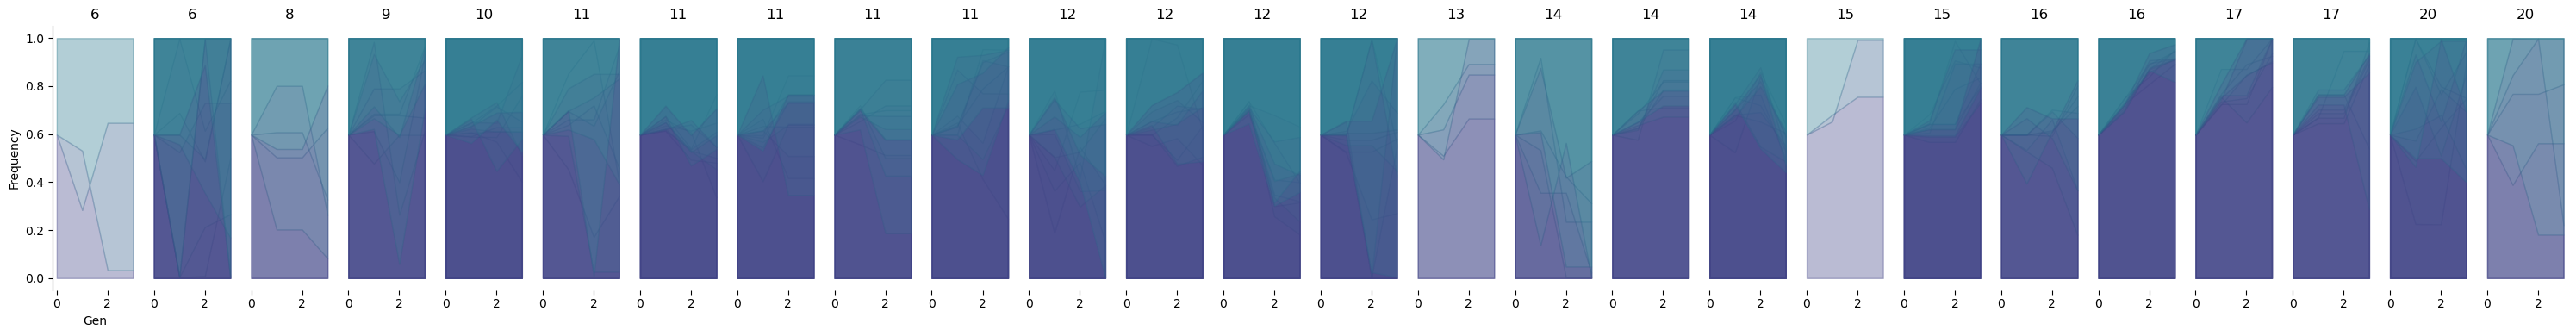

In [41]:
# Explicitly cast the values in each row to float before plotting
bio1_groups = merged_df.groupby('bio1')

# Set the number of columns for the plot grid
n_cols = len(bio1_groups)  # You can adjust this number based on your needs
n_rows = 1
# Create subplots with multiple columns

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(30, 4 * n_rows), sharex=True, sharey=True)

# Flatten axes if we have multiple rows/columns
axes = axes.flatten()

# Plot each group of samples in a different subplot with color-filled areas
for i, (bio1, group) in enumerate(bio1_groups):
    # Plot each row (sample) in the group
    for _, row in group.iterrows():
        x = [0, 1, 2, 3]
        y = row[['0', '1', '2', '3']].astype(float).values  # Convert to float
        
        # Fill the area representing the alternative allele frequency
        axes[i].fill_between(x, 0, y, color=colors[0], alpha=0.2, label='Alt allele freq')
        
        # Fill the area representing the reference allele frequency
        axes[i].fill_between(x, y, 1, color=colors[1], alpha=0.2, label='Ref allele freq')
    
    # Set the title and labels for each subplot
    axes[i].set_title(f'{int(bio1)}')
    axes[i].set_xlabel('Gen')
    
    # For subplots other than the first, remove y-axis labels and ticks
    if i > 0:
        axes[i].set_ylabel('')  # Remove y-axis label
        axes[i].set_xlabel('') 
        axes[i].tick_params(left=False, labelleft=False)  # Remove y-axis ticks and labels
    
    # Remove all spines (rectangles around the plots)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['bottom'].set_visible(False)
    axes[i].spines['left'].set_visible(i == 0)  # Only show the left spine for the first plot

# Set y-axis label and ticks only for the first plot
axes[0].set_ylabel('Frequency')
plt.subplots_adjust(wspace=0, hspace=0)  # Shrink space between subplots
# Adjust layout and show the plot
plt.tight_layout()
plt.show()


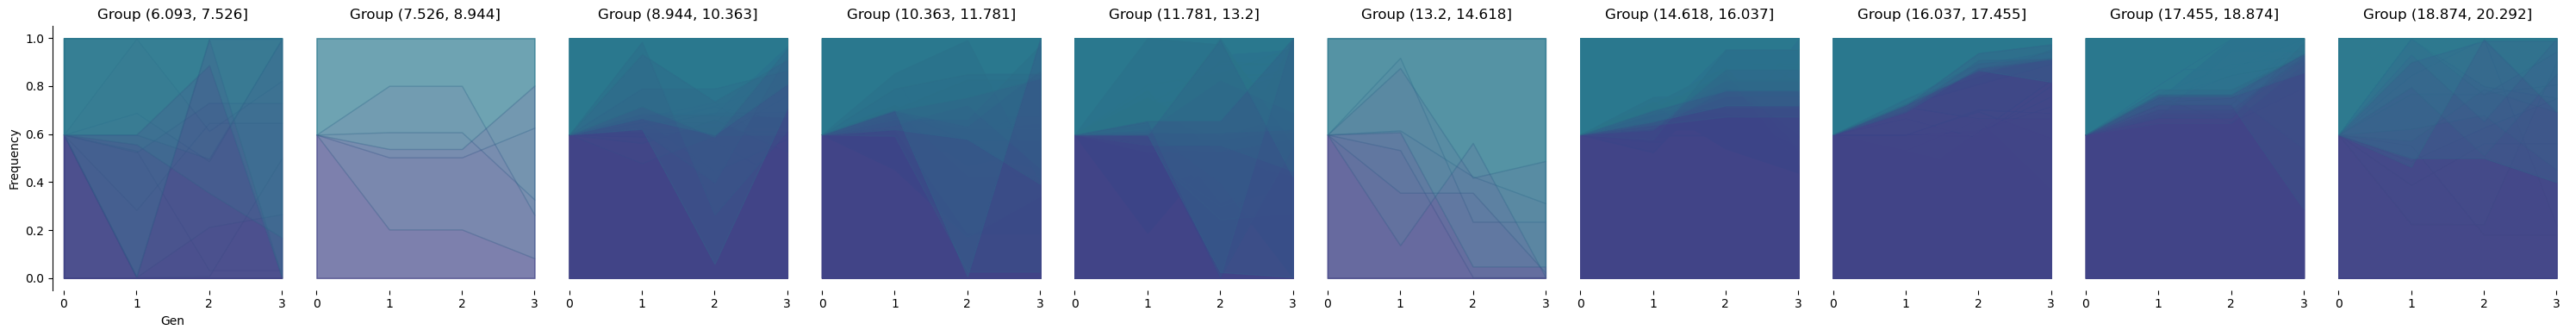

In [42]:
merged_df['bio1_group'] = pd.cut(merged_df['bio1'], bins=10)
# Explicitly cast the values in each row to float before plotting
bio1_groups = merged_df.groupby('bio1_group')

# Set the number of columns for the plot grid
n_cols = len(bio1_groups)  # You can adjust this number based on your needs
n_rows = 1
# Create subplots with multiple columns

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(30, 4 * n_rows), sharex=True, sharey=True)

# Flatten axes if we have multiple rows/columns
axes = axes.flatten()

# Plot each group of samples in a different subplot with color-filled areas
for i, (bio1, group) in enumerate(bio1_groups):
    # Plot each row (sample) in the group
    for _, row in group.iterrows():
        x = [0, 1, 2, 3]
        y = row[['0', '1', '2', '3']].astype(float).values  # Convert to float
        
        # Fill the area representing the alternative allele frequency
        axes[i].fill_between(x, 0, y, color=colors[0], alpha=0.2, label='Alt allele freq')
        
        # Fill the area representing the reference allele frequency
        axes[i].fill_between(x, y, 1, color=colors[1], alpha=0.2, label='Ref allele freq')
    
    # Set the title and labels for each subplot
    axes[i].set_title(f'Group {str(bio1)}')
    axes[i].set_xlabel('Gen')
    
    # For subplots other than the first, remove y-axis labels and ticks
    if i > 0:
        axes[i].set_ylabel('')  # Remove y-axis label
        axes[i].set_xlabel('') 
        axes[i].tick_params(left=False, labelleft=False)  # Remove y-axis ticks and labels
    
    # Remove all spines (rectangles around the plots)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['bottom'].set_visible(False)
    axes[i].spines['left'].set_visible(i == 0)  # Only show the left spine for the first plot

# Set y-axis label and ticks only for the first plot
axes[0].set_ylabel('Frequency')
plt.subplots_adjust(wspace=0, hspace=0)  # Shrink space between subplots
# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [123]:
snps = '2_11534165'
pos = 11534165

usecols = pd.read_csv('../baypass_terminal/merged_hapFIRE_allele_frequency_indexed.csv',nrows =1).columns 
af.columns = usecols

snps_dict_filt = snps_dict_filt.reset_index(drop=True)

causal = pd.concat([af, snps_dict_filt],axis=1)

causal = causal[causal['total_alleles05filter'].notna()]

causal_det = causal[['pos', 'chrom', 'maf05filter', 'total_alleles05filter', 'block']].copy()

causal =causal.drop(['Unnamed: 745', '0','pos', 'chrom', 'maf05filter', 'total_alleles05filter', 'block'],axis=1).set_index('id')

causal_det = causal_det.reset_index(drop=True)

mask = causal_det['pos'] == pos

causal = causal.reset_index(drop=True)

pos2_606065 = causal[mask]



samples = pos2_606065.columns

#clim_sites_during_exp = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/grene/data/bioclimvars_experimental_sites_era5.csv')
clim_sites_during_exp = pd.read_csv('../key_files/bioclimvars_sites_era5_year_2018.csv')

sites_af = pd.Series(samples).str.split('_').str[0].astype(int)

sites_af.name = 'site'

env = sites_af.reset_index().merge(clim_sites_during_exp).drop(['index'],axis=1)

pos2_606065 = pos2_606065.T.reset_index()

pos2_606065.columns = ['sample', 'af']

pos2_606065 = pd.concat([pos2_606065, env[['site', 'bio1']]],axis=1)

pos2_606065['gen'] = pos2_606065['sample'].str.split('_').str[1]
pos2_606065['plot'] = pos2_606065['sample'].str.split('_').str[2]

pos2_606065['site_plot'] = pos2_606065['site'].astype(str) + '_' + pos2_606065['plot'].astype(str)

pos2_pivot= pos2_606065.pivot_table(index = ['site_plot'], columns = 'gen', values = 'af')





p0_average_seed_mix = pd.read_csv('../key_files/p0_average_seed_mix.csv')
snps_dict = pd.read_csv('../key_files/var_pos_grenenet.csv')
p0_average_seed_mix = pd.concat([p0_average_seed_mix,snps_dict ], axis=1)
initial_freq = p0_average_seed_mix[p0_average_seed_mix['id'] == snps]['0'].values[0]

initial_freq



samples_env = pos2_606065[['site_plot', 'bio1']]

samples_env = samples_env.drop_duplicates()

# First, ensure that the 'sample' is reset as a column in pos2_pivot for merging
pos2_pivot_reset = pos2_pivot.reset_index()

# Merge pos2_pivot with samples_env based on the 'sample' column
merged_df = pos2_pivot_reset.merge(samples_env, on='site_plot')

merged_df

merged_df = merged_df.dropna(thresh=2, subset=['1', '2', '3'])

merged_df['0'] = initial_freq

merged_df['bio1_group'] = pd.cut(merged_df['bio1'], bins=10)

merged_df['bio1_group'].unique()



len(bio1_groups)

# Group by the 'bio1' column
bio1_groups = merged_df.groupby('bio1')



merged_df[['0', '1', '2', '3']] = merged_df[['0', '1', '2', '3']].fillna(method='ffill', axis=1)

bio1_groups = merged_df.groupby('bio1_group')

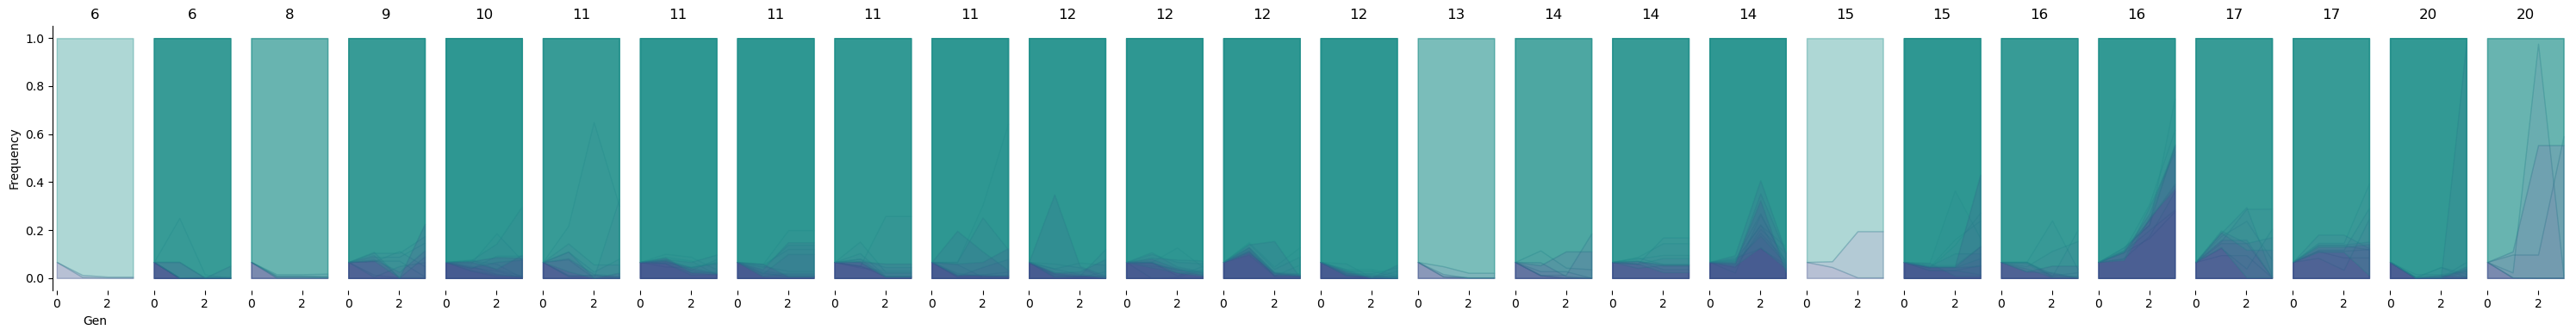

In [125]:
# Explicitly cast the values in each row to float before plotting
bio1_groups = merged_df.groupby('bio1')

# Set the number of columns for the plot grid
n_cols = len(bio1_groups)  # You can adjust this number based on your needs
n_rows = 1
# Create subplots with multiple columns

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(30, 4 * n_rows), sharex=True, sharey=True)

# Flatten axes if we have multiple rows/columns
axes = axes.flatten()

# Plot each group of samples in a different subplot with color-filled areas
for i, (bio1, group) in enumerate(bio1_groups):
    # Plot each row (sample) in the group
    for _, row in group.iterrows():
        x = [0, 1, 2, 3]
        y = row[['0', '1', '2', '3']].astype(float).values  # Convert to float
        
        # Fill the area representing the alternative allele frequency
        axes[i].fill_between(x, 0, y, color=colors[0], alpha=0.2, label='Alt allele freq')
        
        # Fill the area representing the reference allele frequency
        axes[i].fill_between(x, y, 1, color=colors[1], alpha=0.2, label='Ref allele freq')
    
    # Set the title and labels for each subplot
    axes[i].set_title(f'{int(bio1)}')
    axes[i].set_xlabel('Gen')
    
    # For subplots other than the first, remove y-axis labels and ticks
    if i > 0:
        axes[i].set_ylabel('')  # Remove y-axis label
        axes[i].set_xlabel('') 
        axes[i].tick_params(left=False, labelleft=False)  # Remove y-axis ticks and labels
    
    # Remove all spines (rectangles around the plots)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['bottom'].set_visible(False)
    axes[i].spines['left'].set_visible(i == 0)  # Only show the left spine for the first plot

# Set y-axis label and ticks only for the first plot
axes[0].set_ylabel('Frequency')
plt.subplots_adjust(wspace=0, hspace=0)  # Shrink space between subplots
# Adjust layout and show the plot
plt.tight_layout()
plt.show()


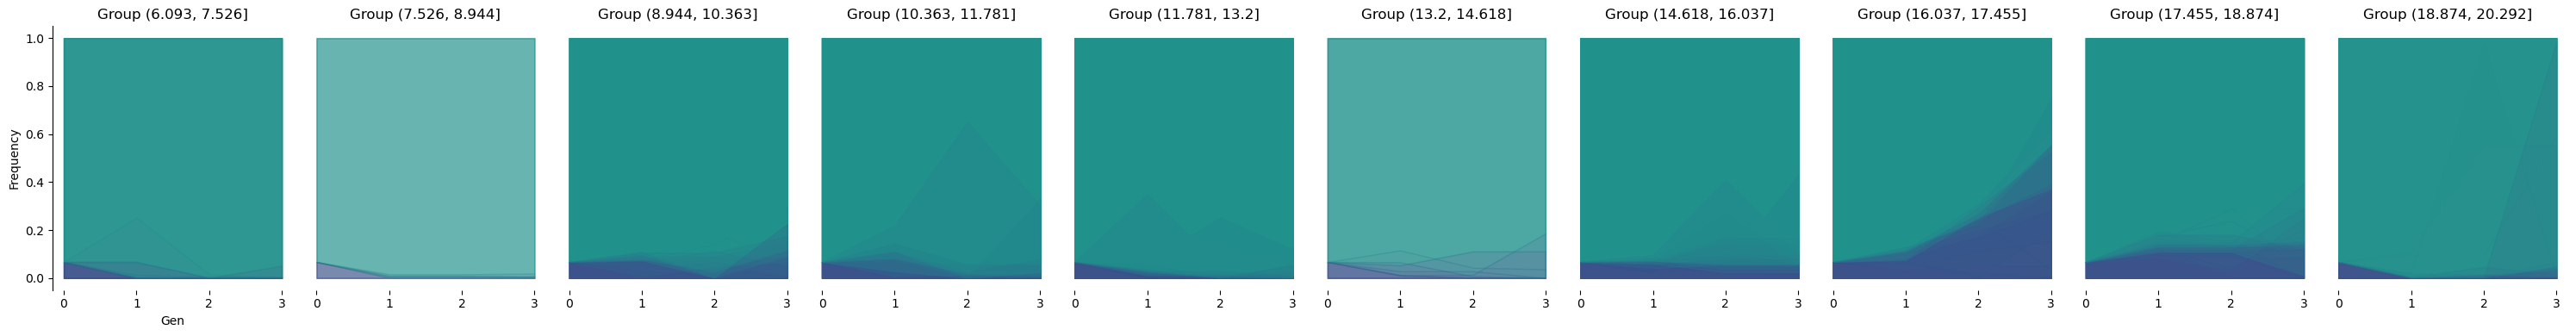

In [124]:
merged_df['bio1_group'] = pd.cut(merged_df['bio1'], bins=10)
# Explicitly cast the values in each row to float before plotting
bio1_groups = merged_df.groupby('bio1_group')

# Set the number of columns for the plot grid
n_cols = len(bio1_groups)  # You can adjust this number based on your needs
n_rows = 1
# Create subplots with multiple columns

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(30, 4 * n_rows), sharex=True, sharey=True)

# Flatten axes if we have multiple rows/columns
axes = axes.flatten()

# Plot each group of samples in a different subplot with color-filled areas
for i, (bio1, group) in enumerate(bio1_groups):
    # Plot each row (sample) in the group
    for _, row in group.iterrows():
        x = [0, 1, 2, 3]
        y = row[['0', '1', '2', '3']].astype(float).values  # Convert to float
        
        # Fill the area representing the alternative allele frequency
        axes[i].fill_between(x, 0, y, color=colors[0], alpha=0.2, label='Alt allele freq')
        
        # Fill the area representing the reference allele frequency
        axes[i].fill_between(x, y, 1, color=colors[1], alpha=0.2, label='Ref allele freq')
    
    # Set the title and labels for each subplot
    axes[i].set_title(f'Group {str(bio1)}')
    axes[i].set_xlabel('Gen')
    
    # For subplots other than the first, remove y-axis labels and ticks
    if i > 0:
        axes[i].set_ylabel('')  # Remove y-axis label
        axes[i].set_xlabel('') 
        axes[i].tick_params(left=False, labelleft=False)  # Remove y-axis ticks and labels
    
    # Remove all spines (rectangles around the plots)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['bottom'].set_visible(False)
    axes[i].spines['left'].set_visible(i == 0)  # Only show the left spine for the first plot

# Set y-axis label and ticks only for the first plot
axes[0].set_ylabel('Frequency')
plt.subplots_adjust(wspace=0, hspace=0)  # Shrink space between subplots
# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [128]:
clim_sites_during_exp = pd.read_csv('../key_files/bioclimvars_sites_era5_year_2018.csv')

In [138]:
clim_sites_during_exp.sort_values('bio1').tail(10)

,site,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
1,2,15.251102,17.574729,44.373954,690.033571,35.668848,-3.937109,39.605957,11.622510,23.999133,24.077096,7.539410,1431.295153,268.721210,21.138613,67.237519,517.957116,137.361701,160.744589,306.871273
29,45,15.279566,21.522744,48.726341,822.793783,40.228418,-3.942236,44.170654,12.560170,26.152377,26.152377,6.559469,535.213458,121.292377,0.700880,76.496701,226.135987,18.953550,18.953550,107.894160
20,28,16.319978,23.272468,48.528985,801.958842,35.705469,-12.250342,47.955811,17.603766,8.363932,25.496879,6.895979,1552.055318,197.816486,58.389257,31.361159,478.838806,286.936265,320.298774,413.586921
3,4,16.571302,19.054634,48.577053,655.652530,38.736963,-0.488623,39.225586,13.561431,24.793653,25.768012,9.856430,1056.532419,424.618561,0.116559,130.911080,589.646135,8.215921,58.440001,543.196012
22,32,17.506254,11.231507,40.307936,591.227968,31.885156,4.020898,27.864258,18.566795,25.062276,25.363597,10.871842,672.257426,131.340930,1.677489,63.003182,270.996493,64.346375,100.384626,215.278524
28,43,17.982793,11.385620,43.045107,616.622639,31.109277,4.658838,26.450439,11.098463,25.610962,25.610962,10.856560,150.441642,33.322979,0.456262,76.253123,75.928333,10.358945,10.358945,72.074863
43,60,18.908464,24.535271,57.315526,659.516505,42.064600,-0.742773,42.807373,12.164064,26.912977,26.912977,10.511094,466.540567,137.325507,0.038494,119.203062,249.169745,0.622671,0.622671,173.691667
11,13,20.153398,22.374817,45.661982,835.762497,42.367578,-6.633398,49.000977,18.999651,24.451598,30.809669,10.586445,1094.256948,266.263351,16.971424,83.683777,509.530576,119.736768,158.519893,261.825362
8,10,20.292248,22.322908,45.759643,834.736536,42.363672,-6.419287,48.782959,19.206040,24.570828,30.892670,10.715132,1104.615337,265.338513,16.984964,83.732801,516.047447,118.475096,168.386115,267.982559
18,26,22.155024,21.154805,59.398191,532.283800,40.641504,5.026270,35.615234,15.137352,27.562259,28.068048,15.137352,122.768634,31.666763,0.324824,94.033110,64.416808,2.211933,2.578514,64.416808


In [133]:
clim_sites_during_exp[clim_sites_during_exp['site']==24]

,site,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
16,24,6.10715,23.774052,49.076038,866.802113,27.357813,-21.085486,48.443298,15.490499,-0.978335,15.490499,-4.952381,1654.701164,253.419736,34.76286,46.17384,610.56325,238.980512,610.56325,418.505085


In [132]:
merged_df['bio1'] = merged_df['bio1'].round()

In [33]:
merged_df['bio1'].unique()

array([20., 14., 13., 10.,  6., 11., 16., 15., 18.,  9., 12., 17.])

In [67]:
merged_df[merged_df['bio1']==18]

,site_plot,1,2,3,bio1,0,bio1_group
134,32_1,0.175374,0.238459,0.076320,18.0,0.067175,"(17.455, 18.874]"
135,32_10,0.095513,NaN,0.002005,18.0,0.067175,"(17.455, 18.874]"
137,32_12,0.145619,NaN,0.004934,18.0,0.067175,"(17.455, 18.874]"
138,32_2,0.125158,0.039771,0.205314,18.0,0.067175,"(17.455, 18.874]"
139,32_3,0.153493,0.288650,0.289285,18.0,0.067175,"(17.455, 18.874]"
140,32_4,0.187311,0.295838,0.012228,18.0,0.067175,"(17.455, 18.874]"
142,32_6,0.197896,0.145727,0.170351,18.0,0.067175,"(17.455, 18.874]"
143,32_7,0.159506,NaN,0.002802,18.0,0.067175,"(17.455, 18.874]"
144,32_8,0.190342,0.117967,NaN,18.0,0.067175,"(17.455, 18.874]"
145,32_9,0.129970,0.002999,NaN,18.0,0.067175,"(17.455, 18.874]"


In [37]:
pwd -P

'/carnegie/nobackup/scratch/tbellagio/gea_grene-net/follow_up_sign_blocks'

In [68]:
gemma_site_4 = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/gea_grene-net/gwas/fitness_gwas/site_32/output/results_lmm.csv')

In [ ]:
2_1265

In [69]:
sing_blocks_site_4 = gemma_site_4.groupby('blocks')['significant'].sum() [gemma_site_4.groupby('blocks')['significant'].sum() != 0]

In [76]:
sing_blocks_site_4.reset_index().head(50)

,blocks,significant
0,1_162,5
1,1_1644,2
2,1_2050,1
3,1_2067,1
4,1_2170,2
5,1_2171,1
6,1_2385,1
7,1_2387,2
8,1_2407,1
9,1_3260,3


In [71]:
sing_blocks_site_4.reset_index().sort_values('significant',ascending=False)

,blocks,significant
59,5_396,13
18,1_724,12
55,5_2610,9
47,4_2584,9
17,1_590,8
...,...,...
37,3_31,1
36,3_2738,1
35,3_1230,1
30,2_508,1


In [72]:
'2_1265' in sing_blocks_site_4.index

False

In [62]:
sing_blocks_site_4.reset_index().sort_values('significant',ascending=False)

,blocks,significant
122,4_2826,106
45,2_1287,61
42,1_663,37
99,3_518,34
74,3_0,29
...,...,...
56,2_1795,1
55,2_1631,1
52,2_1553,1
49,2_1490,1


In [46]:
11533904 - 17417133

-5883229

In [64]:
dict_blocks['2_1287'][0]

'2_12005381'

In [65]:
dict_blocks['2_1265'][0]

'2_11533904'

In [66]:
12005381 - 11533904

471477

In [93]:
merged_df

,site_plot,1,2,3,bio1,0,bio1_group
1,10_10,0.097883,0.097883,0.591492,20.292248,0.067175,"(19.11, 20.292]"
4,10_2,0.023452,0.976681,0.009404,20.292248,0.067175,"(19.11, 20.292]"
7,10_5,0.002444,0.000518,0.000518,20.292248,0.067175,"(19.11, 20.292]"
10,10_8,0.002221,0.000782,0.000782,20.292248,0.067175,"(19.11, 20.292]"
11,10_9,0.110912,0.554074,0.554074,20.292248,0.067175,"(19.11, 20.292]"
...,...,...,...,...,...,...,...
350,9_5,0.017057,0.017057,0.001199,12.665856,0.067175,"(12.018, 13.2]"
351,9_6,0.035835,0.000992,0.000521,12.665856,0.067175,"(12.018, 13.2]"
352,9_7,0.029628,0.002258,0.055451,12.665856,0.067175,"(12.018, 13.2]"
353,9_8,0.011162,0.011162,0.000576,12.665856,0.067175,"(12.018, 13.2]"


/tmp/ipykernel_1591723/3859815869.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df['bio1_group'] = pd.cut(merged_df['bio1'], bins=10)


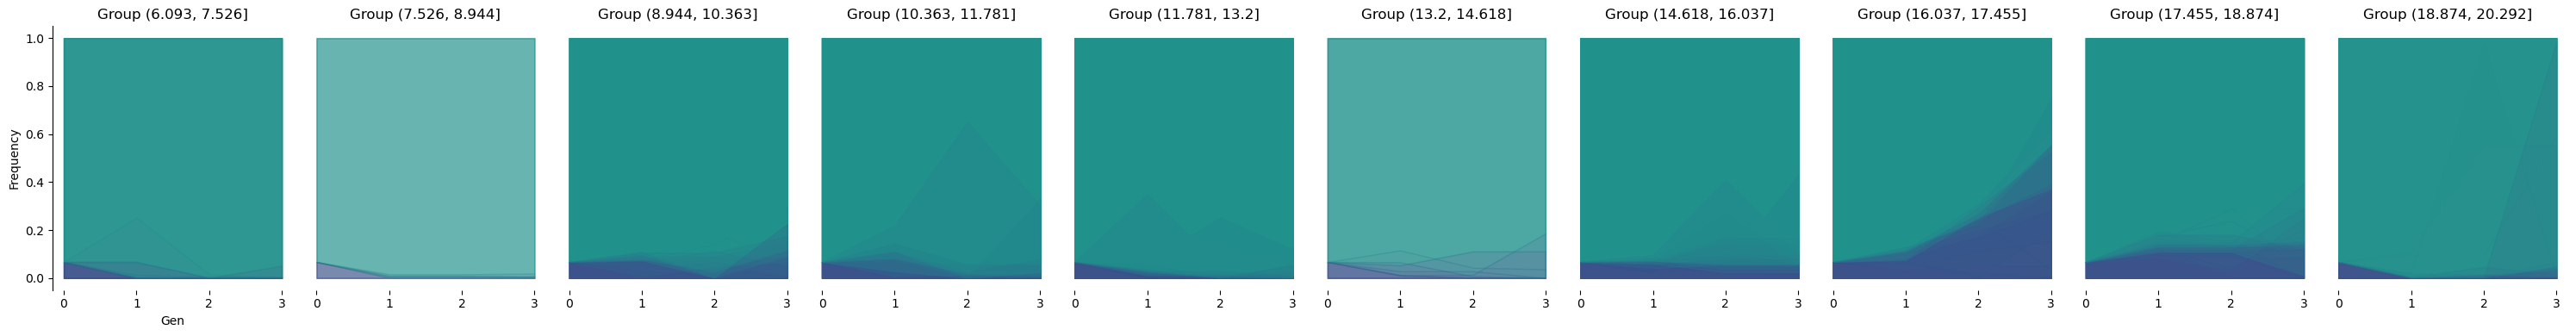

In [95]:
merged_df['bio1_group'] = pd.cut(merged_df['bio1'], bins=10)
# Explicitly cast the values in each row to float before plotting
bio1_groups = merged_df.groupby('bio1_group')

# Set the number of columns for the plot grid
n_cols = len(bio1_groups)  # You can adjust this number based on your needs
n_rows = 1
# Create subplots with multiple columns

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(30, 4 * n_rows), sharex=True, sharey=True)

# Flatten axes if we have multiple rows/columns
axes = axes.flatten()

# Plot each group of samples in a different subplot with color-filled areas
for i, (bio1, group) in enumerate(bio1_groups):
    # Plot each row (sample) in the group
    for _, row in group.iterrows():
        x = [0, 1, 2, 3]
        y = row[['0', '1', '2', '3']].astype(float).values  # Convert to float
        
        # Fill the area representing the alternative allele frequency
        axes[i].fill_between(x, 0, y, color=colors[0], alpha=0.2, label='Alt allele freq')
        
        # Fill the area representing the reference allele frequency
        axes[i].fill_between(x, y, 1, color=colors[1], alpha=0.2, label='Ref allele freq')
    
    # Set the title and labels for each subplot
    axes[i].set_title(f'Group {str(bio1)}')
    axes[i].set_xlabel('Gen')
    
    # For subplots other than the first, remove y-axis labels and ticks
    if i > 0:
        axes[i].set_ylabel('')  # Remove y-axis label
        axes[i].set_xlabel('') 
        axes[i].tick_params(left=False, labelleft=False)  # Remove y-axis ticks and labels
    
    # Remove all spines (rectangles around the plots)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['bottom'].set_visible(False)
    axes[i].spines['left'].set_visible(i == 0)  # Only show the left spine for the first plot

# Set y-axis label and ticks only for the first plot
axes[0].set_ylabel('Frequency')
plt.subplots_adjust(wspace=0, hspace=0)  # Shrink space between subplots
# Adjust layout and show the plot
plt.tight_layout()
plt.show()


In [ ]:
'2_1265'

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

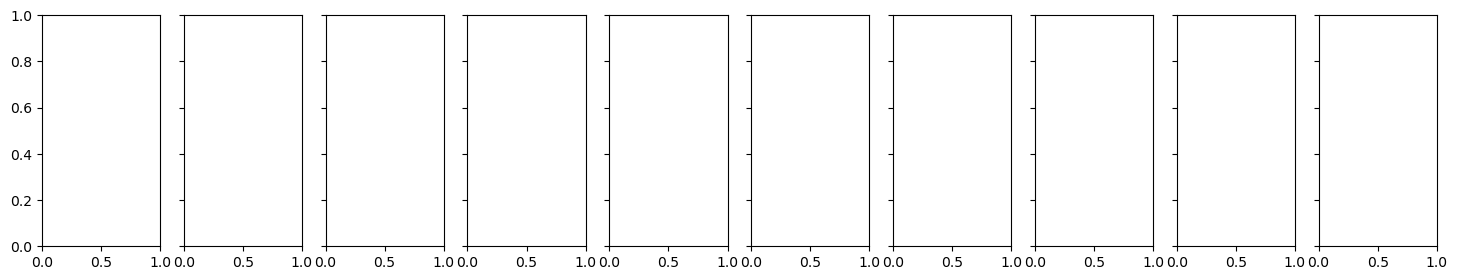

In [50]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Assuming bio1_groups is a dictionary or similar structure
# Create subplots with multiple columns
n_cols = len(bio1_groups)  # You can adjust this number based on your needs
n_rows = math.ceil(len(bio1_groups) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 3 * n_rows), sharex=True, sharey=True)

# Flatten axes if we have multiple rows/columns
axes = axes.flatten()

# Plot each group of samples in a different subplot
for i, (bio1, group) in enumerate(bio1_groups):
    # Plot each row (sample) in the group
    for _, row in group.iterrows():
        values = row[['0', '1', '2', '3']].values
        freq = values / values.sum()  # Convert to relative frequencies
        
        # Prepare the data for the stacked plot
        x = [0, 1, 2, 3]
        y1 = freq  # Frequency
        y2 = 1 - freq  # Complement of frequency

        # Plot the stacked areas
        axes[i].fill_between(x, 0, y1, color='blue', label='freq')
        axes[i].fill_between(x, y1, 1, color='orange', label='1-freq')
    
    # Set the title and labels for each subplot
    axes[i].set_title(f'Bio1')
    axes[i].set_xlabel('Gen')
    axes[i].set_ylabel('Relative Frequency')

# Remove unused subplots if there are any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


In [209]:
#af_filt_blocks = af_filt_blocks.drop('Unnamed: 745',axis=1)

In [19]:
causal

,1_1_1,1_1_2,1_1_3,1_1_4,1_1_5,1_1_6,1_1_7,1_1_8,1_1_9,1_1_10,...,60_1_3,60_1_4,60_1_5,60_1_6,60_1_7,60_1_8,60_1_9,60_1_10,60_1_11,60_1_12
id,,,,,,,,,,,,,,,,,,,,,
2_606065,-0.053716,-0.046983,-0.091463,-0.090044,-0.064925,-0.086582,-0.124436,-0.080972,-0.053968,-0.131020,...,-0.260419,-0.256477,-0.045547,-0.232248,0.187183,-0.130868,-0.120070,-0.230267,-0.249807,-0.059618
2_606118,-0.053716,-0.046983,-0.091463,-0.090044,-0.064925,-0.086582,-0.124436,-0.080972,-0.053968,-0.131020,...,-0.260419,-0.256477,-0.045547,-0.232248,0.187183,-0.130868,-0.120070,-0.230267,-0.249807,-0.059618
2_606124,0.031364,0.006667,0.012723,-0.010902,0.009477,0.024194,-0.010332,-0.002039,0.012303,0.025621,...,-0.015498,0.313520,-0.027005,-0.028331,-0.014963,-0.023843,-0.023846,-0.009218,-0.028349,-0.024980
2_606166,-0.057629,-0.063906,-0.091760,-0.097366,-0.062388,-0.099643,-0.124357,-0.110074,-0.060556,-0.135555,...,-0.257044,-0.252707,-0.041861,-0.228342,0.190882,-0.128670,-0.116274,-0.226702,-0.245825,-0.056631
2_606190,-0.053716,-0.046983,-0.091463,-0.090044,-0.064925,-0.086582,-0.124436,-0.080972,-0.053968,-0.131020,...,-0.260419,-0.256477,-0.045547,-0.232248,0.187183,-0.130868,-0.120070,-0.230267,-0.249807,-0.059618
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5_19685291,-0.023648,-0.015333,-0.027204,-0.009965,-0.028725,0.011284,-0.027460,-0.020514,-0.030474,0.011657,...,-0.045801,0.426635,-0.060026,-0.016837,0.080039,-0.044176,-0.048305,-0.047620,-0.058375,-0.054268
5_19685375,-0.027750,-0.015519,0.010510,0.013452,-0.016344,0.027554,0.014634,0.016001,0.001907,0.012710,...,-0.007048,0.378586,-0.030178,0.043337,0.034908,-0.083717,0.346253,-0.055837,0.062181,-0.074170
5_19685384,-0.117077,-0.035809,-0.008876,0.016223,0.034097,-0.033899,-0.004072,0.067427,0.054777,0.038217,...,0.067504,0.244475,0.210742,0.316421,0.004216,-0.047872,0.221585,0.306534,0.137721,0.194178


In [45]:
first_gen = pd.read_csv('../key_files/generation_1_sample_names.txt',header=None)[0]

In [47]:
causal_first_gen = causal[first_gen]

In [48]:
samples = causal_first_gen.columns

#clim_sites_during_exp = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/grene/data/bioclimvars_experimental_sites_era5.csv')
clim_sites_during_exp = pd.read_csv('../key_files/bioclimvars_sites_era5_year_2018.csv')

sites_af = pd.Series(samples).str.split('_').str[0].astype(int)

sites_af.name = 'site'

env = sites_af.reset_index().merge(clim_sites_during_exp).drop(['index'],axis=1)

bio1 = env['bio1']

In [ ]:
causal_values = causal_first_gen.reset_index().drop(columns='id').T

In [49]:
bio1

0      10.209418
1      10.209418
2      10.209418
3      10.209418
4      10.209418
         ...    
321    18.908464
322    18.908464
323    18.908464
324    18.908464
325    18.908464
Name: bio1, Length: 326, dtype: float64

In [54]:
bio1

0      10.209418
1      10.209418
2      10.209418
3      10.209418
4      10.209418
         ...    
321    18.908464
322    18.908464
323    18.908464
324    18.908464
325    18.908464
Name: bio1, Length: 326, dtype: float64

In [55]:
causal_values

,0,1,2,3,4,5,6,7,8,9,...,68,69,70,71,72,73,74,75,76,77
1_1_1,84.860414,90.256724,90.256724,90.256724,87.876052,90.256724,90.256724,90.256724,90.256724,186.060364,...,31.514780,61.640722,61.807984,118.677968,104.991004,119.620396,180.586172,27.336430,117.794928,27.033098
1_1_2,140.096628,148.440342,148.440342,148.440342,138.494160,148.440342,148.440342,148.440342,148.440342,309.650644,...,36.706078,86.127956,88.719118,226.834430,199.665072,231.371046,268.181334,49.748866,227.797316,34.406994
1_1_3,121.420890,124.278620,124.278620,124.278620,122.200860,124.278620,124.278620,124.278620,124.278620,295.851394,...,44.715170,126.438948,126.696148,238.731446,214.238642,241.618668,293.207544,60.400144,234.316654,42.530192
1_1_4,121.608636,127.110914,127.110914,127.110914,121.723384,127.110914,127.110914,127.110914,127.110914,276.200494,...,56.018382,125.899614,126.779614,254.394172,216.668144,256.422446,283.331022,62.826318,250.105286,48.890750
1_1_5,132.106036,134.645726,134.645726,134.645726,133.876392,134.645726,134.645726,134.645726,134.645726,275.176526,...,59.194984,115.540372,116.155402,252.393996,231.153006,258.917004,270.043486,47.470938,250.670678,57.109876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60_1_8,11.124780,11.133414,11.133414,11.133414,11.035416,11.133414,11.133414,11.133414,11.133414,28.143630,...,7.530804,12.310590,12.432372,22.800174,20.525352,22.874148,29.024274,1.807248,22.685394,7.410090
60_1_9,3.398114,3.398418,3.398418,3.398418,3.392208,3.398418,3.398418,3.398418,3.398418,3.741678,...,0.226966,6.734398,6.998008,10.352578,10.133752,10.425948,10.562512,6.546690,10.388972,0.218036
60_1_10,4.263028,5.566974,5.566974,5.566974,5.538666,5.566974,5.566974,5.566974,5.566974,22.185814,...,18.255524,21.943138,22.005704,36.513568,35.696374,36.557822,35.698376,2.752302,34.734756,18.224738
60_1_11,4.495180,4.520290,4.520290,4.520290,4.509970,4.520290,4.520290,4.520290,4.520290,15.590040,...,6.580410,13.857510,13.956510,26.321510,19.474690,26.367500,19.759000,7.341970,26.328200,6.571890


In [58]:
# Create a dictionary that maps each block to a specific color
block_color_dict = {
    '2_199': 'blue',
    '3_2730': 'green',
    '5_2244': 'red'
}

In [60]:
block_rows

Index([ 31,  34,  39,  42,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,
        62,  63,  64,  66,  67,  68,  70,  71,  72,  73,  74,  75,  77,  78,
        80,  81,  83,  84,  87,  88,  90,  92,  94,  95, 100, 102, 103, 104,
       105, 107, 113],
      dtype='int64')

In [64]:
causal_det = causal_det.reset_index(drop=True)

In [65]:
 causal_det['block'].unique()

array(['2_199', '3_2730', '5_2244'], dtype=object)

In [70]:
bio1.index = causal_values.index

,0,1,2,3,4,5,6,7,8,9,...,68,69,70,71,72,73,74,75,76,77
1_1_1,84.860414,90.256724,90.256724,90.256724,87.876052,90.256724,90.256724,90.256724,90.256724,186.060364,...,31.514780,61.640722,61.807984,118.677968,104.991004,119.620396,180.586172,27.336430,117.794928,27.033098
1_1_2,140.096628,148.440342,148.440342,148.440342,138.494160,148.440342,148.440342,148.440342,148.440342,309.650644,...,36.706078,86.127956,88.719118,226.834430,199.665072,231.371046,268.181334,49.748866,227.797316,34.406994
1_1_3,121.420890,124.278620,124.278620,124.278620,122.200860,124.278620,124.278620,124.278620,124.278620,295.851394,...,44.715170,126.438948,126.696148,238.731446,214.238642,241.618668,293.207544,60.400144,234.316654,42.530192
1_1_4,121.608636,127.110914,127.110914,127.110914,121.723384,127.110914,127.110914,127.110914,127.110914,276.200494,...,56.018382,125.899614,126.779614,254.394172,216.668144,256.422446,283.331022,62.826318,250.105286,48.890750
1_1_5,132.106036,134.645726,134.645726,134.645726,133.876392,134.645726,134.645726,134.645726,134.645726,275.176526,...,59.194984,115.540372,116.155402,252.393996,231.153006,258.917004,270.043486,47.470938,250.670678,57.109876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60_1_8,11.124780,11.133414,11.133414,11.133414,11.035416,11.133414,11.133414,11.133414,11.133414,28.143630,...,7.530804,12.310590,12.432372,22.800174,20.525352,22.874148,29.024274,1.807248,22.685394,7.410090
60_1_9,3.398114,3.398418,3.398418,3.398418,3.392208,3.398418,3.398418,3.398418,3.398418,3.741678,...,0.226966,6.734398,6.998008,10.352578,10.133752,10.425948,10.562512,6.546690,10.388972,0.218036
60_1_10,4.263028,5.566974,5.566974,5.566974,5.538666,5.566974,5.566974,5.566974,5.566974,22.185814,...,18.255524,21.943138,22.005704,36.513568,35.696374,36.557822,35.698376,2.752302,34.734756,18.224738
60_1_11,4.495180,4.520290,4.520290,4.520290,4.509970,4.520290,4.520290,4.520290,4.520290,15.590040,...,6.580410,13.857510,13.956510,26.321510,19.474690,26.367500,19.759000,7.341970,26.328200,6.571890


In [68]:
causal_values[row]

1_1_1      27.033098
1_1_2      34.406994
1_1_3      42.530192
1_1_4      48.890750
1_1_5      57.109876
             ...    
60_1_8      7.410090
60_1_9      0.218036
60_1_10    18.224738
60_1_11     6.571890
60_1_12     4.971220
Name: 77, Length: 326, dtype: float64

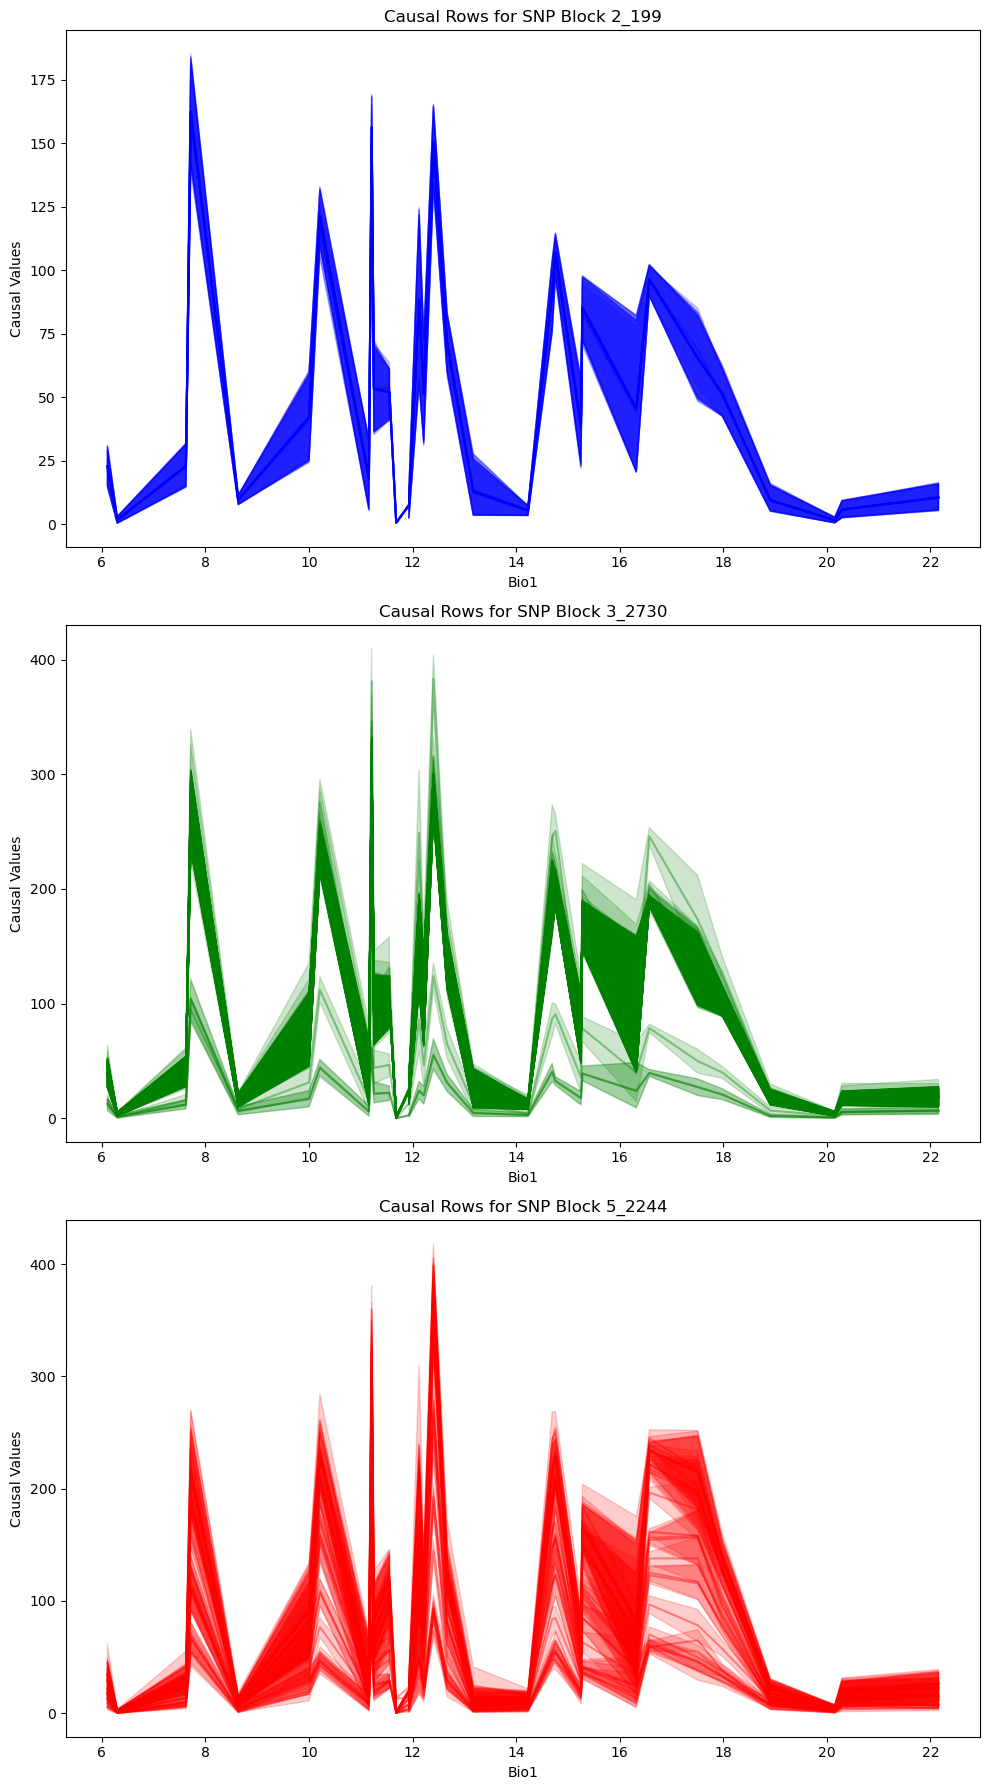

In [71]:

# Identify unique blocks from your data
unique_blocks = causal_det['block'].unique()

# Create subplots: one for each unique block
fig, axes = plt.subplots(nrows=len(unique_blocks), figsize=(10, 6 * len(unique_blocks)))

# If there's only one unique block, `axes` will not be an array, so we make it one
if len(unique_blocks) == 1:
    axes = [axes]

# Plot each row of causal as a line in the corresponding subplot
for i, block in enumerate(unique_blocks):
    # Filter the rows corresponding to the current block
    block_rows = causal_det[causal_det['block'] == block].index
    color = block_color_dict[block]
    
    for row in block_rows:
        sns.lineplot(x=bio1, y=causal_values[row], ax=axes[i], label=f'Row {row + 1}', color=color, alpha=0.4, legend=False)
    
    # Set labels and title for each subplot
    axes[i].set_title(f'Causal Rows for SNP Block {block}')
    axes[i].set_xlabel('Bio1')
    axes[i].set_ylabel('Causal Values')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()


/tmp/ipykernel_3555521/1189033000.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


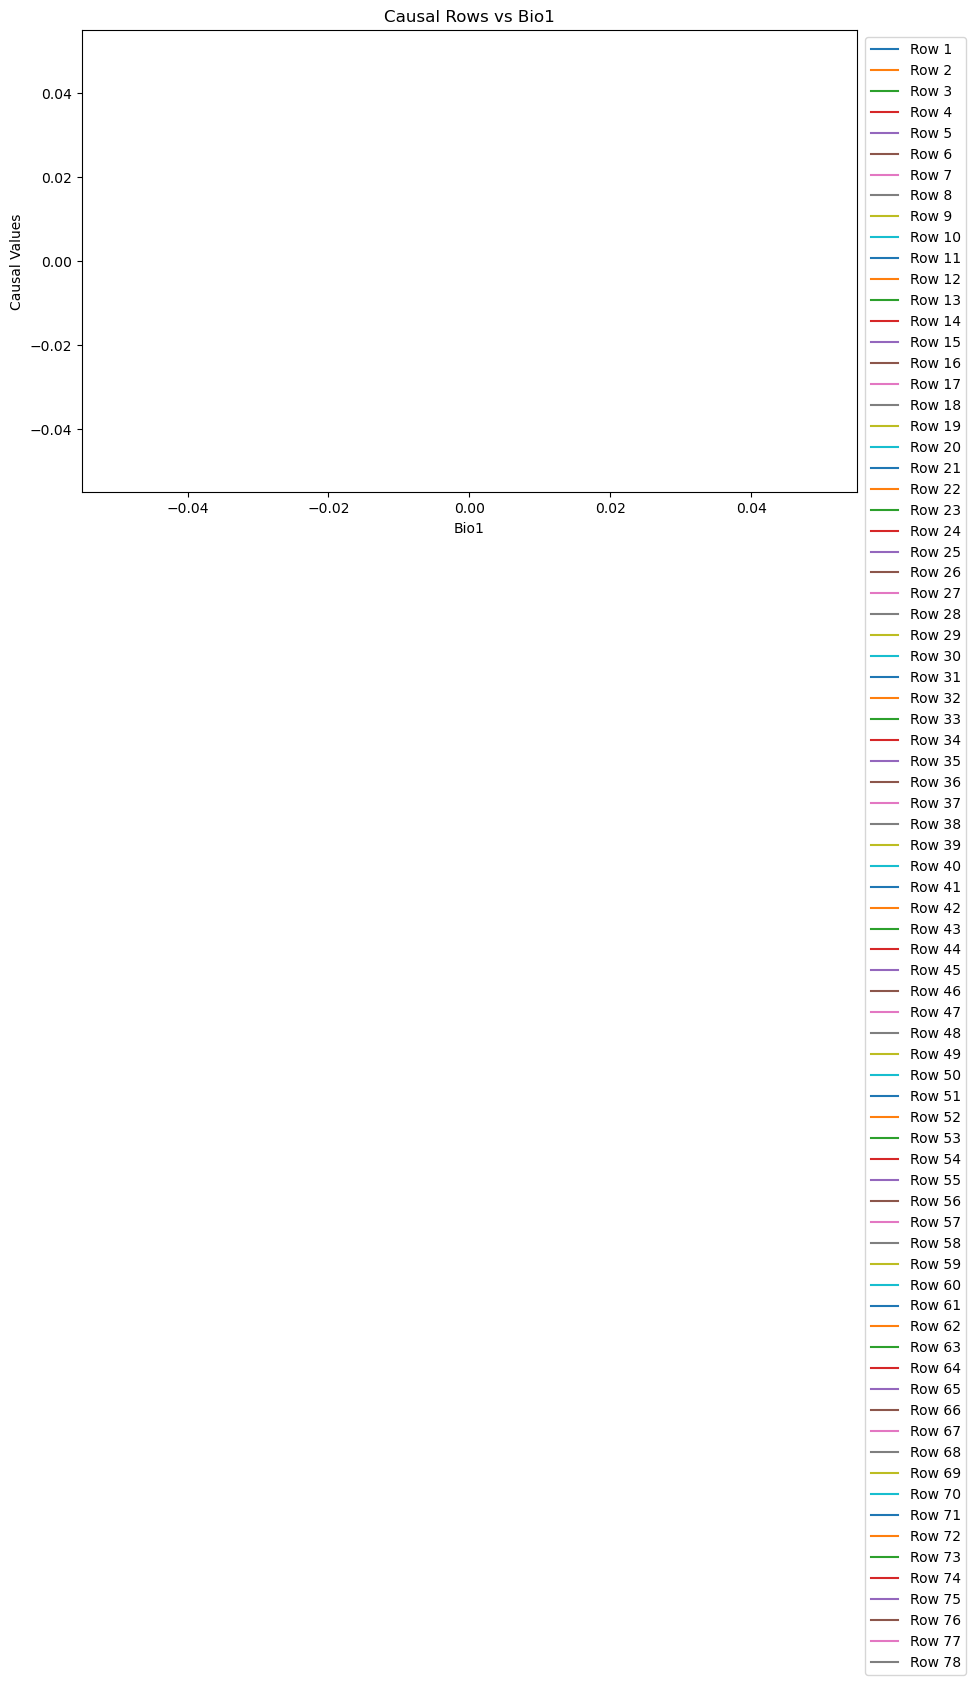

In [53]:
# Create the seaborn plot
plt.figure(figsize=(10, 6))

# Plot each row of causal as a line using seaborn
for i in range(causal_values.shape[1]):
    sns.lineplot(x=bio1, y=causal_values[i], label=f'Row {i+1}')

# Adding labels and title
plt.xlabel('Bio1')
plt.ylabel('Causal Values')
plt.title('Causal Rows vs Bio1')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

# Show the plot
plt.tight_layout()
plt.show()

In [118]:
## cehcking that the awk filtering is working 
#(snps_dict_filt['id'].values == af_filt_blocks['0'].values).all()

True

In [18]:
first_gen = pd.read_csv('../key_files/generation_1_sample_names.txt',header=None)[0]

In [247]:
causal_first_gen = causal[first_gen]

In [240]:
causal_loci_save = causal.index

In [248]:
causal_values = causal_first_gen.reset_index().drop(columns='id').T

In [278]:
causal_values = pd.concat([causal_values,bio1],axis=1)

In [286]:
causal_values = causal_values.groupby('bio1')[[     0,      1,      2,      3,      4,      5,      6,      7,      8,
            9,     10,     11,     12,     13,     14,     15,     16,     17,
           18,     19,     20,     21,     22,     23,     24,     25,     26,
           27,     28,     29,     30,     31,     32,     33,     34,     35,
           36,     37,     38,     39,     40,     41,     42,     43,     44,
           45,     46,     47,     48,     49,     50,     51,     52,     53,
           54,     55,     56,     57,     58,     59,     60,     61,     62,
           63,     64,     65,     66,     67,     68,     69,     70,     71,
           72,     73,     74,     75,     76,     77,]].mean()

In [295]:
causal_values = causal_values.reset_index(drop=True)

In [296]:
causal_values.shape

(31, 78)

In [251]:
samples = causal_first_gen.columns

#clim_sites_during_exp = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/grene/data/bioclimvars_experimental_sites_era5.csv')
clim_sites_during_exp = pd.read_csv('../key_files/bioclimvars_sites_era5_year_2018.csv')

sites_af = pd.Series(samples).str.split('_').str[0].astype(int)

sites_af.name = 'site'

env = sites_af.reset_index().merge(clim_sites_during_exp).drop(['index'],axis=1)

bio1 = env['bio1']

In [292]:
bio1 =bio1.reset_index(drop=True).drop_duplicates().reset_index(drop=True)

In [252]:
bio1.index = causal_values.index

In [253]:
causal_values.shape[1]

78

In [254]:
causal_values[1]

1_1_1     -0.053716
1_1_2     -0.046983
1_1_3     -0.091463
1_1_4     -0.090044
1_1_5     -0.064925
             ...   
60_1_8    -0.130868
60_1_9    -0.120070
60_1_10   -0.230267
60_1_11   -0.249807
60_1_12   -0.059618
Name: 1, Length: 326, dtype: float64

In [257]:
causal_values[i]

1_1_1     -0.008183
1_1_2     -0.012412
1_1_3      0.005365
1_1_4     -0.013998
1_1_5     -0.013806
             ...   
60_1_8    -0.028385
60_1_9    -0.023339
60_1_10    0.165001
60_1_11   -0.006004
60_1_12   -0.032682
Name: 9, Length: 326, dtype: float64

In [261]:
causal_det = causal_det.reset_index(drop=True)

In [266]:
# Create a dictionary that maps each block to a specific color
block_color_dict = {
    '2_199': 'blue',
    '3_2730': 'green',
    '5_2244': 'red'
}

In [267]:
snp_block = causal_det.loc[i,'block']

'green'

In [269]:
snp_block[block_color_dict]

TypeError: string indices must be integers

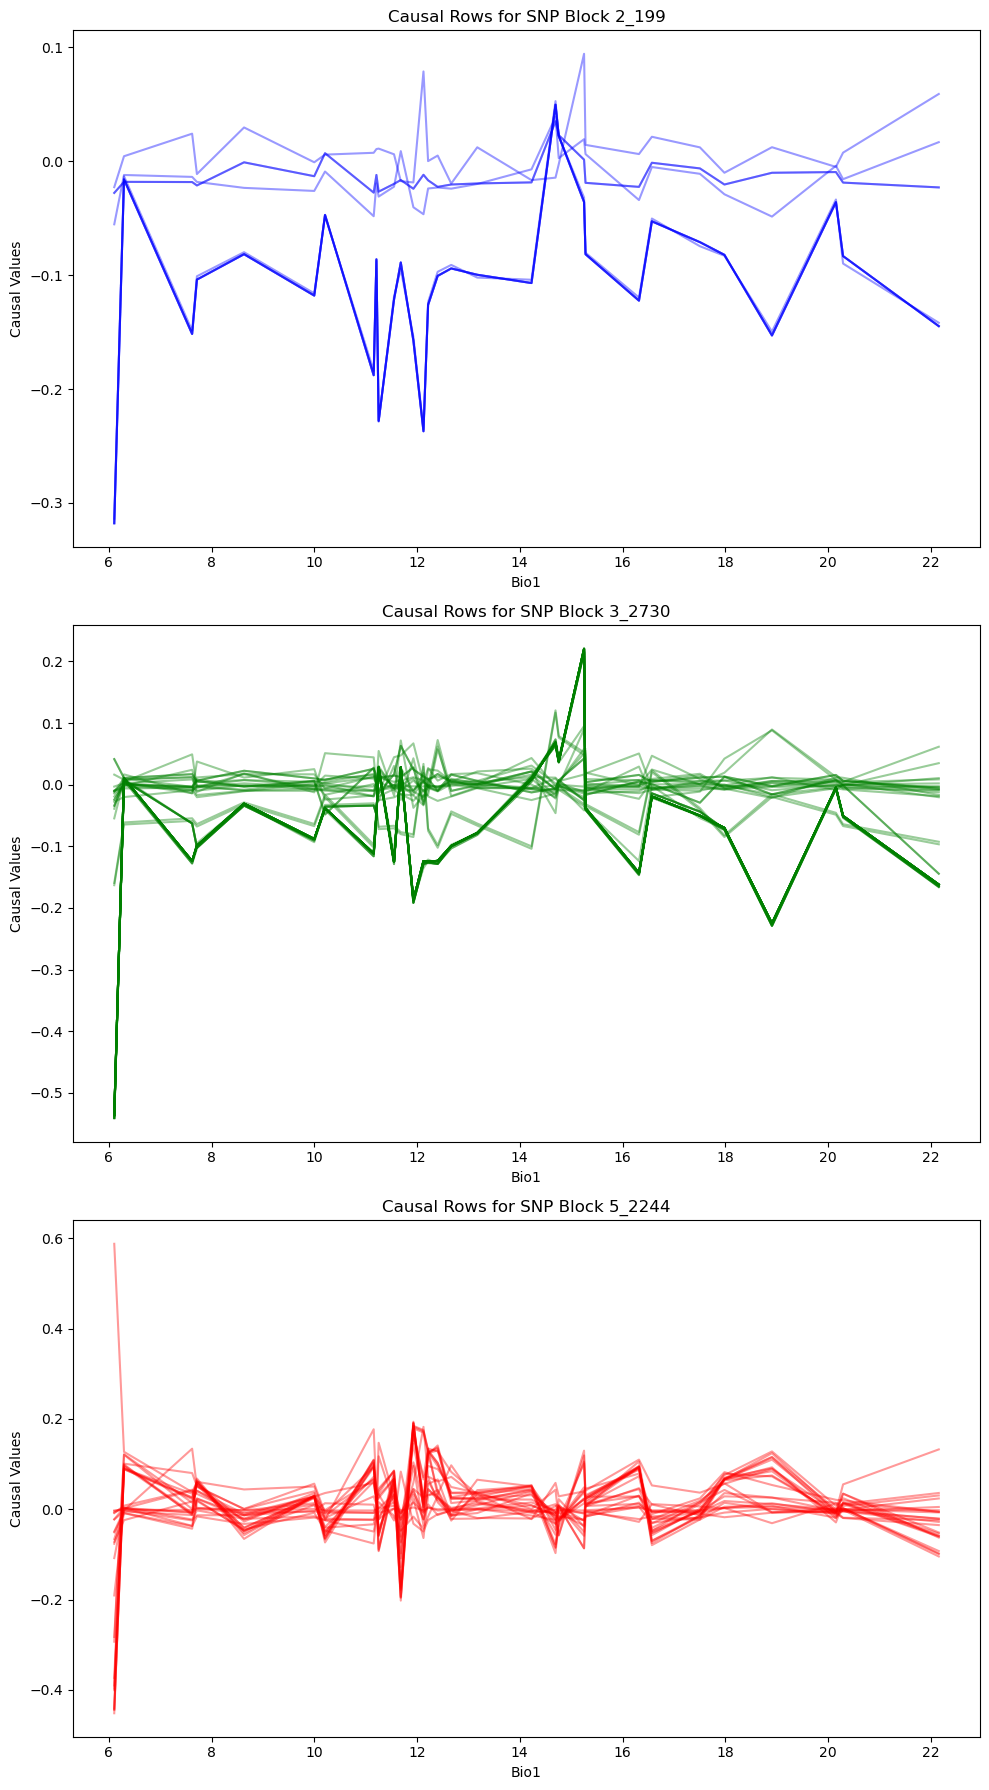

In [301]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify unique blocks from your data
unique_blocks = causal_det['block'].unique()

# Create subplots: one for each unique block
fig, axes = plt.subplots(nrows=len(unique_blocks), figsize=(10, 6 * len(unique_blocks)))

# If there's only one unique block, `axes` will not be an array, so we make it one
if len(unique_blocks) == 1:
    axes = [axes]

# Plot each row of causal as a line in the corresponding subplot
for i, block in enumerate(unique_blocks):
    # Filter the rows corresponding to the current block
    block_rows = causal_det[causal_det['block'] == block].index
    color = block_color_dict[block]
    
    for row in block_rows:
        sns.lineplot(x=bio1, y=causal_values[row], ax=axes[i], label=f'Row {row + 1}', color=color, alpha=0.4, legend=False)
    
    # Set labels and title for each subplot
    axes[i].set_title(f'Causal Rows for SNP Block {block}')
    axes[i].set_xlabel('Bio1')
    axes[i].set_ylabel('Causal Values')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()


In [259]:
causal_values.shape[1]

78

/tmp/ipykernel_3504670/1189033000.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


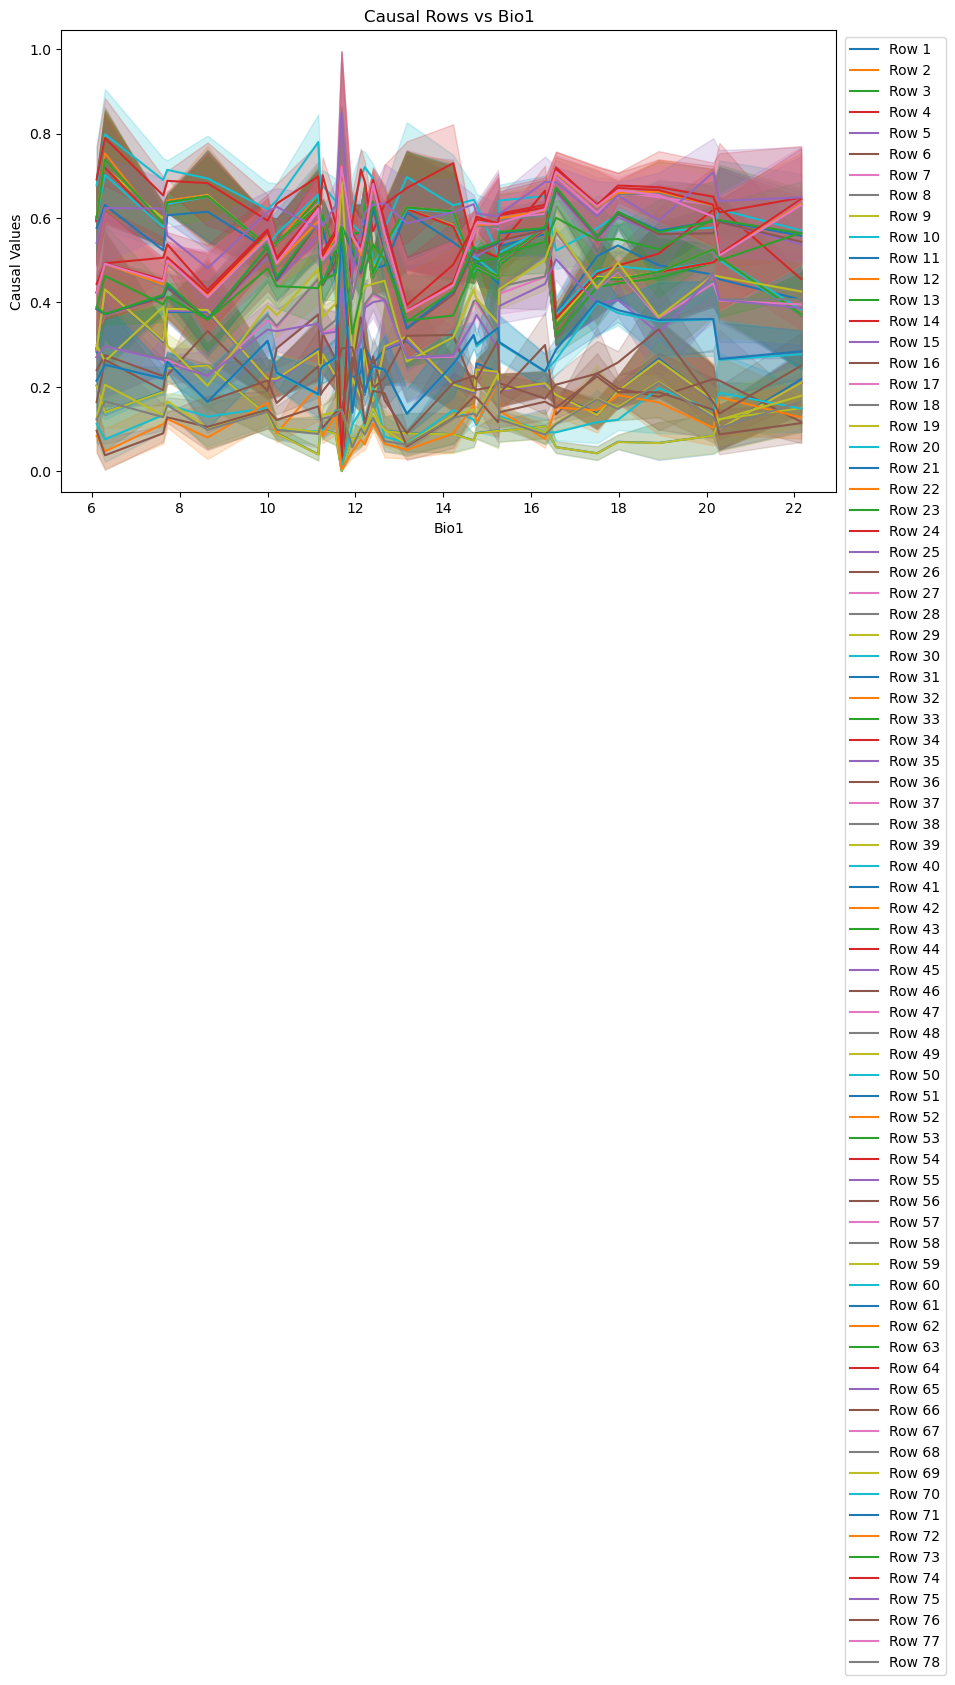

In [182]:
# Create the seaborn plot
plt.figure(figsize=(10, 6))

# Plot each row of causal as a line using seaborn
for i in range(causal_values.shape[1]):
    sns.lineplot(x=bio1, y=causal_values[i], label=f'Row {i+1}')

# Adding labels and title
plt.xlabel('Bio1')
plt.ylabel('Causal Values')
plt.title('Causal Rows vs Bio1')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

# Show the plot
plt.tight_layout()
plt.show()

In [169]:
# Create the seaborn plot
plt.figure(figsize=(10, 6))

# Plot each row of causal as a line using seaborn
for i in range(causal.shape[1]):
    sns.lineplot(x=bio1, y=causal[i], label=f'Row {i+1}')

# Adding labels and title
plt.xlabel('Bio1')
plt.ylabel('Causal Values')
plt.title('Causal Rows vs Bio1')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

# Show the plot
plt.tight_layout()
plt.show()

KeyError: 0

<Figure size 1000x600 with 0 Axes>

In [ ]:
causal = af_filt_blocks.merge(snps_dict_filt, right_on = 'id', left_on = '0')

causal.columns

causal = causal[causal['total_alleles05filter'].notna()].drop(['0', 'pos', 'chrom', 'maf05filter', 'total_alleles05filter', 'block'],axis=1).set_index('id')

samples = causal.columns

#clim_sites_during_exp = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/grene/data/bioclimvars_experimental_sites_era5.csv')
clim_sites_during_exp = pd.read_csv('../key_files/bioclimvars_sites_era5_year_2018.csv')

sites_af = pd.Series(samples).str.split('_').str[0].astype(int)

sites_af.name = 'site'

env = sites_af.reset_index().merge(clim_sites_during_exp).drop(['index'],axis=1)

bio1 = env['bio1']

In [162]:
import seaborn as sns


KeyError: 'x'

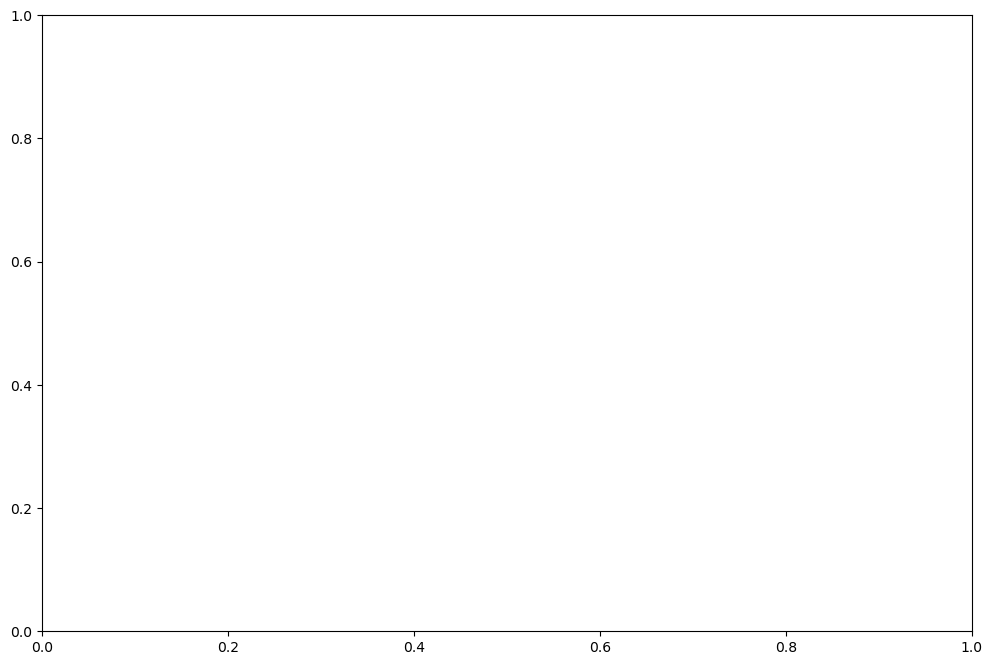

In [163]:
# Reset index to turn 'id' into a column
causal_reset = causal.reset_index()
causal_reset.rename(columns={'index': 'id'}, inplace=True)

# Melt the DataFrame to long format
causal_melted = causal_reset.melt(id_vars='id', var_name='bio1_index', value_name='value')

# Map the bio1 values
causal_melted['bio1'] = causal_melted['bio1_index'].map(bio1.to_dict())

# Create a line plot for each row in the causal DataFrame using Seaborn
plt.figure(figsize=(12, 8))  # Adjust figure size as needed

sns.lineplot(data=causal_melted, x='bio1', y='value', hue='id', palette='tab20', alpha=0.7)

# Add labels and title
plt.xlabel('bio1')
plt.ylabel('Values from causal DataFrame')
plt.title('Line Plot of Each Row in Causal DataFrame Against bio1')
plt.legend(title='Row', bbox_to_anchor=(1.05, 1), loc='upper left')  # Adjust legend placement as needed
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

In [141]:
import matplotlib.pyplot as plt

In [148]:
import numpy as np


In [160]:
# Reset index to turn 'id' into a column
causal_reset = causal.reset_index()
causal_reset.rename(columns={'index': 'id'}, inplace=True)

# Melt the DataFrame to long format
causal_melted = causal_reset.melt(id_vars='id', var_name='bio1_index', value_name='value')
causal_melted['bio1'] = bio1[causal_melted['bio1_index']].values

KeyError: "None of [Index(['1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1',\n       '1_1_1', '1_1_1',\n       ...\n       '60_1_12', '60_1_12', '60_1_12', '60_1_12', '60_1_12', '60_1_12',\n       '60_1_12', '60_1_12', '60_1_12', '60_1_12'],\n      dtype='object', length=58110)] are in the [index]"

In [159]:

# Create a line plot for each row in the causal DataFrame using Seaborn
plt.figure(figsize=(12, 8))  # Adjust figure size as needed

sns.lineplot(data=causal_melted, x='bio1', y='value', hue='id', palette='tab20', alpha=0.7)

# Add labels and title
plt.xlabel('bio1')
plt.ylabel('Values from causal DataFrame')
plt.title('Line Plot of Each Row in Causal DataFrame Against bio1')
plt.legend(title='Row', bbox_to_anchor=(1.05, 1), loc='upper left')  # Adjust legend placement as needed
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

KeyError: "None of [Index(['1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1',\n       '1_1_1', '1_1_1',\n       ...\n       '60_1_12', '60_1_12', '60_1_12', '60_1_12', '60_1_12', '60_1_12',\n       '60_1_12', '60_1_12', '60_1_12', '60_1_12'],\n      dtype='object', length=58110)] are in the [index]"

In [146]:
# Prepare the data for Seaborn
causal_melted = causal.reset_index().melt(id_vars='id', var_name='bio1_index', value_name='value')
causal_melted['bio1'] = bio1[causal_melted['bio1_index']].values

KeyError: "None of [Index(['1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1',\n       '1_1_1', '1_1_1',\n       ...\n       '60_1_12', '60_1_12', '60_1_12', '60_1_12', '60_1_12', '60_1_12',\n       '60_1_12', '60_1_12', '60_1_12', '60_1_12'],\n      dtype='object', length=58110)] are in the [index]"

In [143]:


# Create a line plot for each row in the causal DataFrame using Seaborn
plt.figure(figsize=(12, 8))  # Adjust figure size as needed

sns.lineplot(data=causal_melted, x='bio1', y='value', hue='row', palette='tab20', alpha=0.7)

# Add labels and title
plt.xlabel('bio1')
plt.ylabel('Values from causal DataFrame')
plt.title('Line Plot of Each Row in Causal DataFrame Against bio1')
plt.legend(title='Row', bbox_to_anchor=(1.05, 1), loc='upper left')  # Adjust legend placement as needed
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

KeyError: 'index'

In [32]:
mask = snps_dict['block'].isin(genes).reset_index(drop=True)

In [57]:
new_mask = mask.loc[:899999]

In [35]:
ddf = dd.read_csv('../key_files/merged_hapFIRE_allele_frequency.txt', sep = '\t')

In [36]:
af = ddf.compute()


KeyboardInterrupt



In [ ]:
af = af.reset_index()

In [ ]:
af[mask]

In [ ]:



# Compute the number of NaNs per row
nan_count_per_row = ddf.isna().sum(axis=1)

# Filter the DataFrame
filtered_ddf = ddf[nan_count_per_row < 326]

f_fst = filtered_ddf.compute()

In [9]:
af = pd.read_csv('../key_files/allele_freq_maf05_mincount05_firstgensamples_windexsnpid.csv')


KeyboardInterrupt



In [ ]:
'../key_files/p0_average_seed_mix.csv'